In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/california-housing-prices/housing.csv


In [2]:
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

'''
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
'''


'\nfrom sklearn.preprocessing import PowerTransformer, QuantileTransformer\nfrom sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso\nfrom sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor\n'

## 1. 資料載入與初步檢查

首先載入資料，並檢查欄位型別、缺失值與整體結構，確認是否有重複資料或異常欄位。


In [3]:
df=pd.read_csv("/kaggle/input/california-housing-prices/housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [6]:
df[df.isnull().any(axis=1)]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [7]:
def outlier_percent(df):
    numeric_col=df.select_dtypes(include=np.number).columns.tolist()
    for c in numeric_col:
        col = df[c].dropna()  
        q1 = col.quantile(0.25)
        q3 = col.quantile(0.75)
        iqr = q3 - q1 #Interquartile range
        fence_low  = q1-1.5*iqr
        fence_high = q3+1.5*iqr
        lower_out = len(col[(col < fence_low)])
        upper_out = len(col[(col > fence_high)])
        outlier_count = upper_out+lower_out
        prop_out = outlier_count/len(df[c])
        print(c, ": "+"{:.2%}".format(prop_out))

outlier_percent(df)

longitude : 0.00%
latitude : 0.00%
housing_median_age : 0.00%
total_rooms : 6.24%
total_bedrooms : 6.16%
population : 5.79%
households : 5.91%
median_income : 3.30%
median_house_value : 5.19%


In [8]:
df_nonull=df.copy()
df_nonull["total_bedrooms"]=df_nonull["total_bedrooms"].fillna(df_nonull["total_bedrooms"].median())
df_nonull.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 2. 資料清理與特徵工程

對有缺失值的欄位進行填補，並衍生新的特徵（例如每戶平均房間數、人口密度等），這些常用於房價預測任務中。類別型變數也需轉為數值。


In [9]:
#衍生特徵
#df["rooms_per_household"] = df["total_rooms"] / df["households"]
#df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
#df["population_per_household"] = df["population"] / df["households"]


In [10]:
def show_dist(df,numeric_col):
    df[numeric_col].plot(kind='kde', subplots=True, layout=(3, 3), figsize=(15, 10), sharex=False)
    plt.suptitle("KDE Plots of Numeric Columns", fontsize=16)
    plt.tight_layout()
    plt.show()

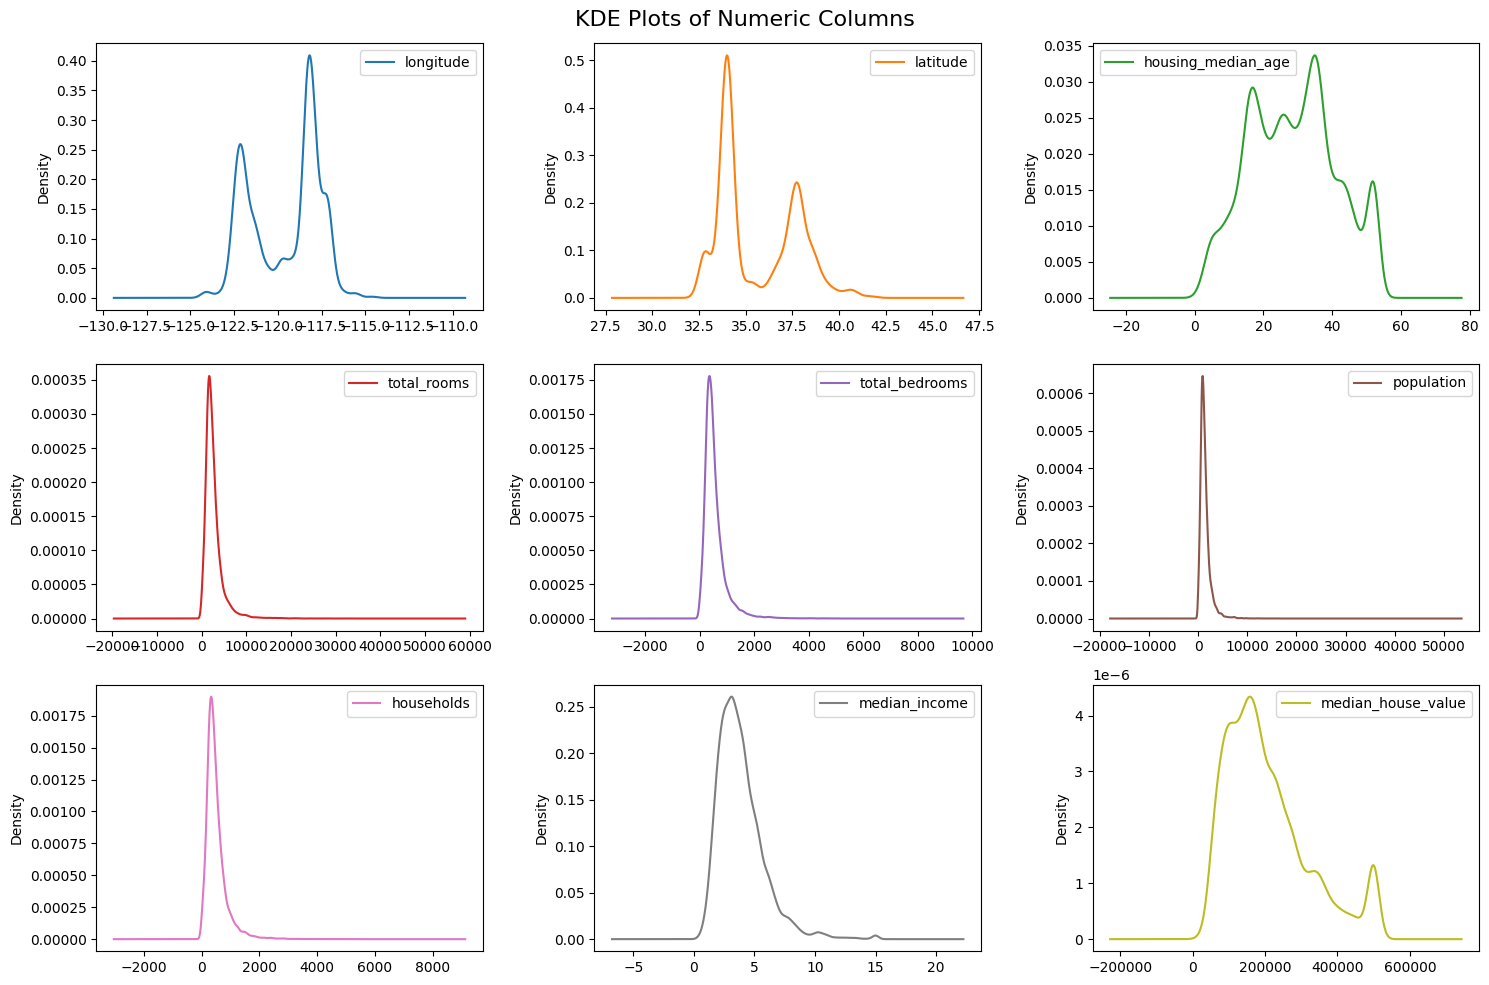

In [11]:
numeric_col=df_nonull.select_dtypes(include=np.number).columns.tolist()
show_dist(df_nonull,numeric_col)

In [12]:
df_nonull[numeric_col].skew()

longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.481141
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64

In [13]:
df_tran = df_nonull.copy()
log_numeric_col = []
sqrt_numeric_col = []
'''
boxcox_col = []
yeojohnson_col = []
quantile_col = []
'''
for col in numeric_col:
    skewness = df_tran[col].skew()
    if skewness >= 1:
        # === Log & Sqrt ===
        df_tran[f'log_{col}'] = np.log1p(df_tran[col])
        df_tran[f'sqrt_{col}'] = np.sqrt(df_tran[col])
        log_numeric_col.append(f'log_{col}')
        sqrt_numeric_col.append(f'sqrt_{col}')

        '''
        # === Box-Cox (strictly > 0 only) ===
        if (df_tran[col] > 0).all():
            pt_boxcox = PowerTransformer(method='box-cox')
            df_tran[f'boxcox_{col}'] = pt_boxcox.fit_transform(df_tran[[col]])
            boxcox_col.append(f'boxcox_{col}')
        

        # === Yeo-Johnson (handles 0s, negatives) ===
        pt_yeo = PowerTransformer(method='yeo-johnson')
        df_tran[f'yeojohnson_{col}'] = pt_yeo.fit_transform(df_tran[[col]])
        yeojohnson_col.append(f'yeojohnson_{col}')

        # === Quantile Transformer (Gaussian) ===
        qt = QuantileTransformer(output_distribution='normal', random_state=0)
        df_tran[f'quantile_{col}'] = qt.fit_transform(df_tran[[col]])
        quantile_col.append(f'quantile_{col}')
        '''

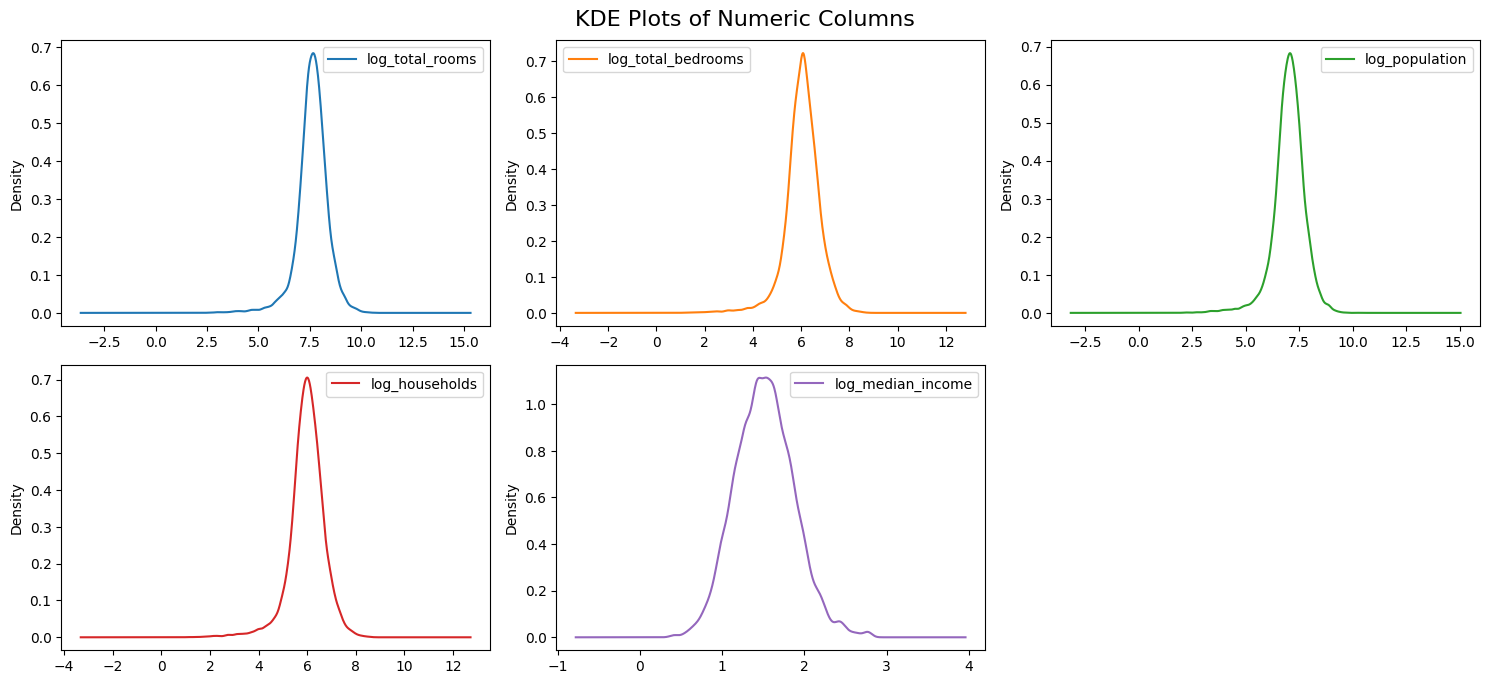

In [14]:
show_dist(df_tran,log_numeric_col )

In [15]:
df_tran[log_numeric_col].skew()

log_total_rooms      -1.075533
log_total_bedrooms   -0.998768
log_population       -1.044087
log_households       -1.051607
log_median_income     0.226083
dtype: float64

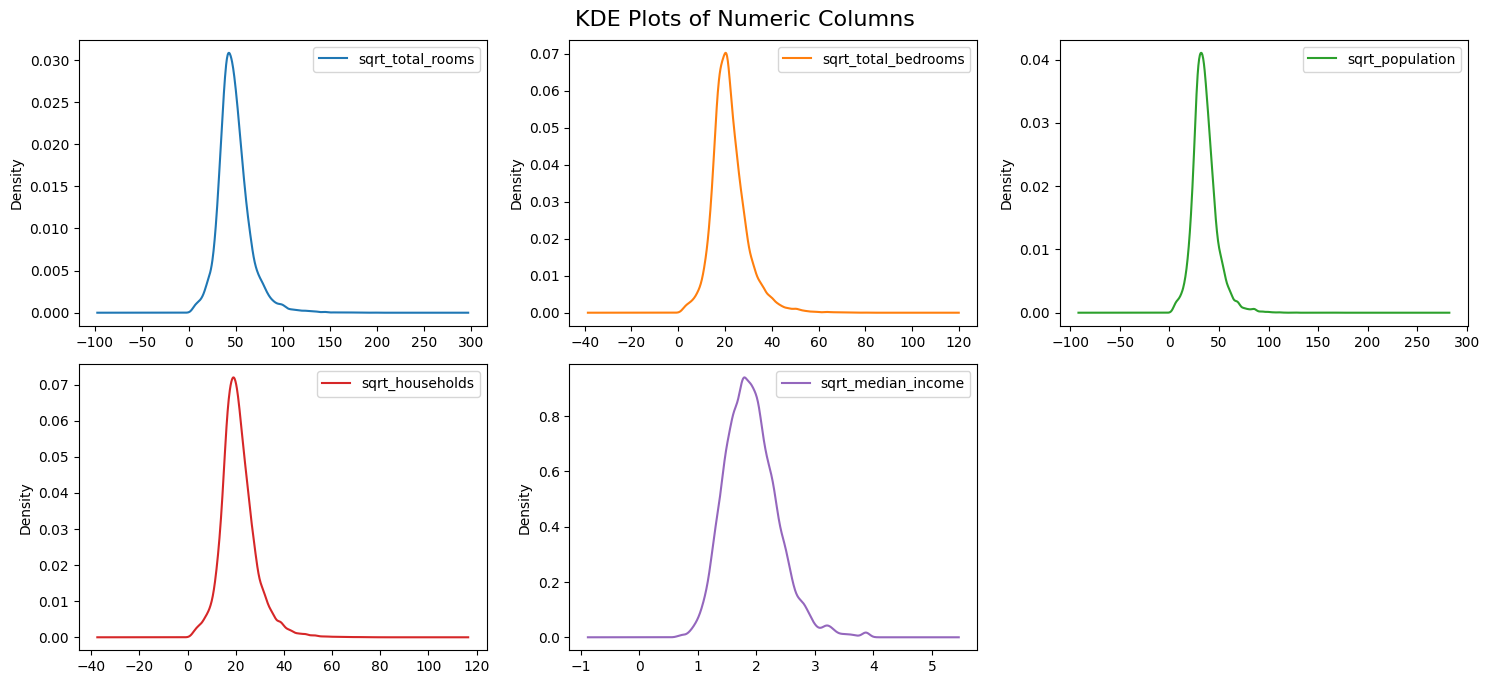

In [16]:
show_dist(df_tran,sqrt_numeric_col )

In [17]:
df_tran[sqrt_numeric_col].skew()

sqrt_total_rooms       1.355500
sqrt_total_bedrooms    1.215939
sqrt_population        1.224655
sqrt_households        1.126872
sqrt_median_income     0.689225
dtype: float64

In [18]:
#show_dist(df_tran,boxcox_col )

In [19]:
#df_tran[boxcox_col].skew()

In [20]:
#show_dist(df_tran,yeojohnson_col )

In [21]:
#df_tran[yeojohnson_col].skew()

In [22]:
#show_dist(df_tran,quantile_col )

In [23]:
#df_tran[quantile_col].skew()

In [24]:
outlier_percent(df_tran)

longitude : 0.00%
latitude : 0.00%
housing_median_age : 0.00%
total_rooms : 6.24%
total_bedrooms : 6.33%
population : 5.79%
households : 5.91%
median_income : 3.30%
median_house_value : 5.19%
log_total_rooms : 4.64%
sqrt_total_rooms : 4.47%
log_total_bedrooms : 4.05%
sqrt_total_bedrooms : 4.39%
log_population : 4.11%
sqrt_population : 3.98%
log_households : 4.27%
sqrt_households : 4.22%
log_median_income : 1.09%
sqrt_median_income : 1.92%


In [25]:
# Select numeric columns
scaler = StandardScaler()
df_scaled = df_tran.copy()
numeric_col=df_scaled.select_dtypes(include=np.number).columns.tolist()
df_scaled[numeric_col] = scaler.fit_transform(df_scaled[numeric_col])


In [26]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   longitude            20640 non-null  float64
 1   latitude             20640 non-null  float64
 2   housing_median_age   20640 non-null  float64
 3   total_rooms          20640 non-null  float64
 4   total_bedrooms       20640 non-null  float64
 5   population           20640 non-null  float64
 6   households           20640 non-null  float64
 7   median_income        20640 non-null  float64
 8   median_house_value   20640 non-null  float64
 9   ocean_proximity      20640 non-null  object 
 10  log_total_rooms      20640 non-null  float64
 11  sqrt_total_rooms     20640 non-null  float64
 12  log_total_bedrooms   20640 non-null  float64
 13  sqrt_total_bedrooms  20640 non-null  float64
 14  log_population       20640 non-null  float64
 15  sqrt_population      20640 non-null 

In [27]:
df_scaled.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,log_total_rooms,sqrt_total_rooms,log_total_bedrooms,sqrt_total_bedrooms,log_population,sqrt_population,log_households,sqrt_households,log_median_income,sqrt_median_income
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.603626e-15,-1.046536e-15,6.609700e-17,1.652425e-17,-8.812933e-17,-1.377021e-17,7.160508e-17,5.508083e-17,-9.363741e-17,1.321940e-15,-7.711317e-17,8.812933e-17,-2.588799e-16,-9.528984e-16,-4.131062e-17,7.683776e-16,5.508083e-18,-1.982910e-16,3.910739e-16
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.277688e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-1.662641e+00,-8.708000e+00,-2.720333e+00,-7.415413e+00,-2.759500e+00,-7.659682e+00,-2.736750e+00,-7.281394e+00,-2.778333e+00,-3.099229e+00,-2.674655e+00
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.718868e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-7.561633e-01,-4.679108e-01,-5.971589e-01,-4.949031e-01,-6.158304e-01,-4.835575e-01,-6.136837e-01,-4.765882e-01,-6.081329e-01,-6.866501e-01,-6.949090e-01
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.428309e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-2.353337e-01,4.474966e-02,-1.294589e-01,3.139976e-02,-1.374153e-01,4.983434e-02,-1.222099e-01,4.328334e-02,-1.266550e-01,-1.453727e-02,-7.698901e-02
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.537334e-01,2.644949e-01,2.758427e-01,4.593063e-01,5.014973e-01,5.673050e-01,4.493708e-01,5.713884e-01,4.575680e-01,5.814287e-01,4.735687e-01,5.809338e-01,4.765461e-01,6.441326e-01,5.824507e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.408779e+01,3.025033e+01,1.460152e+01,5.858286e+00,2.540411e+00,3.933658e+00,8.689693e+00,3.756639e+00,7.709579e+00,4.695510e+00,1.235979e+01,3.754597e+00,7.841095e+00,3.500723e+00,4.336098e+00


In [28]:
df_scaled["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [29]:
#df_encoded = pd.get_dummies(df_scaled, columns=["ocean_proximity"], drop_first=False)
encoder = OneHotEncoder(drop=None, sparse_output=False)
encoded_array = encoder.fit_transform(df_scaled[["ocean_proximity"]])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(["ocean_proximity"]))
df_encoded = pd.concat([df_scaled.drop("ocean_proximity", axis=1).reset_index(drop=True), encoded_df], axis=1)


In [30]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   log_total_rooms             20640 non-null  float64
 10  sqrt_total_rooms            20640 non-null  float64
 11  log_total_bedrooms          20640 non-null  float64
 12  sqrt_total_bedrooms         20640 non-null  float64
 13  log_population              206

## 3. 特徵選擇、調超參數和交叉驗證比較

使用 `SelectKBest` 搭配 F-score 做特徵選擇、透過 GridSearchCV 找出最佳參數和交叉驗證(CrossValidation )表現比較，視覺化各個特徵與目標變數的關聯強度。


In [31]:
def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name} Evaluation:")
    print(f"  MSE: {mse:.2f}")
    print(f"  R²: {r2:.2%}")
    return mse, r2

### 解釋：

* `evaluate`: 函式名稱，代表評估模型。
* `model`: 接收任何具有 `.predict()` 方法的模型（如 scikit-learn 模型）。
* `X_test`: 測試資料的特徵（Features）。
* `y_test`: 測試資料的實際標籤（Target）。
* `name="Model"`: 預設名稱參數，若使用者沒提供就顯示 "Model"。

### 計算評估指標：MSE & R²

```python
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
```

### 解釋：

* `mean_squared_error(...)`：

  * 計算預測值與真實值之間的平均平方誤差（MSE）。
  * MSE 越小表示預測越準確（但對極端值很敏感）。
* `r2_score(...)`：

  * 計算決定係數 R²，代表模型預測變異量的解釋比例。
  * R² 範圍理論上為 (−∞, 1]，1 表示完美預測，0 表示與常數模型一樣差。

[MSE scikit](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#mean-squared-error)

[R2 scikit](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [32]:




def run_manual_pipeline(X, y, variant_name, k_features=13):
    print(f"\n====== {variant_name.upper()} VARIANT ======")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    selector = SelectKBest(score_func=f_regression, k=k_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    selected_features = X.columns[selector.get_support()]
    print(f"Selected Features ({k_features}):", list(selected_features))


    lr = LinearRegression()
    lr_cv = cross_val_score(lr, X_train_selected, y_train, cv=5, scoring='r2')
    lr.fit(X_train_selected, y_train)
    print("Linear Regression CV R2 Mean:", lr_cv.mean())
    evaluate(lr, X_test_selected, y_test, name=f"Linear Regression ({variant_name})")

    # === SGD Regressor Grid Search ===
    sgd = SGDRegressor(random_state=42)
    sgd_param_grid = {
        "loss": ["squared_error", "huber"],
        "penalty": ["l2", "l1", "elasticnet"],
        "alpha": [1e-4, 1e-3, 1e-2],
        "max_iter": [500, 1000],
    }

    sgd_grid = GridSearchCV(sgd, sgd_param_grid, cv=5, scoring="r2", n_jobs=-1)
    sgd_grid.fit(X_train_selected, y_train)

    print("Best SGD Parameters:", sgd_grid.best_params_)
    print("Best SGD CV R2:", sgd_grid.best_score_)
    evaluate(sgd_grid.best_estimator_, X_test_selected, y_test, name=f"SGD Regressor ({variant_name})")



### 特徵選擇：SelectKBest

[SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html)

```python
selector = SelectKBest(score_func=f_regression, k=k_features)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)
```

### 說明：

* `SelectKBest` 是一種單變數（univariate）特徵選擇方法。
* 使用 `f_regression` 計算每個特徵與目標變數之間的線性關聯強度（F-statistics）。
* `fit_transform()`：根據訓練資料擬合並選出 top-k 特徵。
* `transform()`：應用同樣的選擇規則到測試資料。


### f\_regression 是什麼？

`f_regression` 是一個評估 **線性迴歸關聯性** 的打分函數，用來計算每個特徵與目標變數 `y` 的 **F 分數（F-statistic）** 和 p-value。

### 它的數學機制是：

對每個特徵 $x_i$，計算：

* **F 分數**（F-statistic）：衡量該特徵在解釋 `y` 的變異上有多大貢獻
* 越大代表越顯著

具體計算步驟：

1. 假設你有特徵 $x_i$ 與目標變數 $y$
2. 拿 $x_i$ 去做線性回歸預測 $y$：$y = a x_i + b$
3. 算出模型解釋的變異（SSR）和總變異（SST）
4. F-score = $\frac{\text{Explained Variance}}{\text{Unexplained Variance}}$

這個分數越大，表示該特徵與 `y` 的線性關聯越強 → 越值得保留

---

### 印出被選中的特徵

```python
selected_features = X.columns[selector.get_support()]
print(f"Selected Features ({k_features}):", list(selected_features))
```

### 說明：

* `selector.get_support()` 回傳一個布林陣列，表示哪些欄位被選上。
* 對照 `X.columns` 找出實際欄位名稱並列印。

---

### 線性回歸訓練與交叉驗證

[cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

```python
lr = LinearRegression()
lr_cv = cross_val_score(lr, X_train_selected, y_train, cv=5, scoring='r2')
lr.fit(X_train_selected, y_train)
```

### 說明：

* 建立 `LinearRegression` 模型
* 使用 `cross_val_score()` 做 **5-fold 交叉驗證**，評估訓練集上模型的一致性
* 用 `fit()` 正式訓練模型

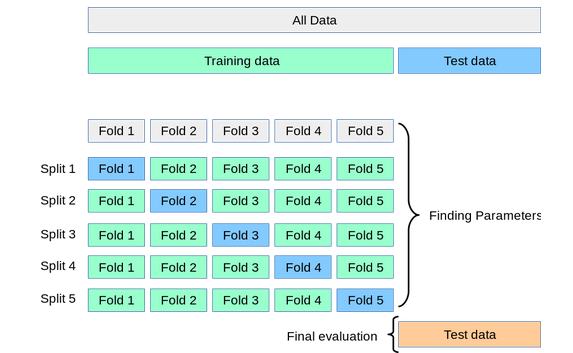

### 評估線性回歸表現

```python
print("Linear Regression CV R2 Mean:", lr_cv.mean())
evaluate(lr, X_test_selected, y_test, name=f"Linear Regression ({variant_name})")
```

### 說明：

* 印出交叉驗證的平均 R² 分數
* 呼叫前面自訂的 `evaluate()` 函式，印出測試集上的 MSE 與 R²

---

###  SGDRegressor 超參數搜尋



```python
sgd = SGDRegressor(random_state=42)
sgd_param_grid = {
    "loss": ["squared_error", "huber"],
    "penalty": ["l2", "l1", "elasticnet"],
    "alpha": [1e-4, 1e-3, 1e-2],
    "max_iter": [500, 1000],
}
```

### 說明：

* `SGDRegressor` 是一種使用隨機梯度下降的線性模型，適合大規模資料或需要正則化的情境
* `param_grid` 定義了要嘗試的參數組合（共 3x3x3x2 = 54 種組合）

---

### Grid Search 調參 + 模型訓練

[GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

```python
sgd_grid = GridSearchCV(sgd, sgd_param_grid, cv=5, scoring="r2", n_jobs=-1)
sgd_grid.fit(X_train_selected, y_train)
```
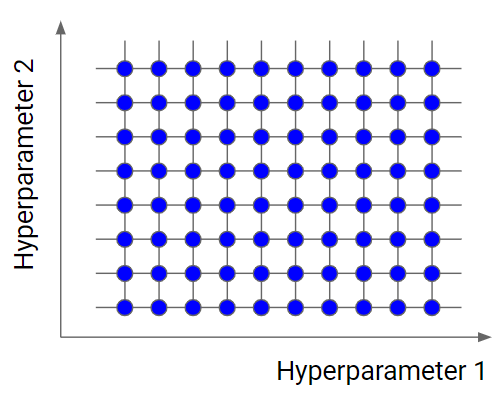

### 說明：

* `GridSearchCV` 自動測試所有參數組合
* `cv=5` 表示每個組合都用 5-fold CV 評估
* `n_jobs=-1` 讓 Grid Search 使用所有 CPU 核心加速

---

### 輸出最佳參數與評估

```python
print("Best SGD Parameters:", sgd_grid.best_params_)
print("Best SGD CV R2:", sgd_grid.best_score_)
evaluate(sgd_grid.best_estimator_, X_test_selected, y_test, name=f"SGD Regressor ({variant_name})")
```

### 說明：

* 印出在交叉驗證中表現最佳的參數組合
* 使用 `.best_estimator_` 對測試集做預測與評估

---


In [33]:

target = df_encoded["median_house_value"]

# Exclude the label column and keep transformed or original sets
common_cat_cols = [col for col in df_encoded.columns if col.startswith("ocean_proximity_")]

# Original
original_cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households", "median_income"
] + common_cat_cols

# Log-transformed
log_cols = [
    "longitude", "latitude", "housing_median_age",
] + common_cat_cols+log_numeric_col

# Sqrt-transformed
sqrt_cols = [
    "longitude", "latitude", "housing_median_age",
] + common_cat_cols+sqrt_numeric_col

# boxcox-transformed
'''
boxcox_cols = [
    "longitude", "latitude", "housing_median_age",
] + common_cat_cols+boxcox_col
'''
# yeojohnson-transformed
'''
yeojohnson_cols = [
    "longitude", "latitude", "housing_median_age",
] + common_cat_cols+yeojohnson_col
'''
# quantile-transformed
'''
quantile_cols = [
    "longitude", "latitude", "housing_median_age",
] + common_cat_cols+quantile_col
'''
data_tran={
"original_cols":original_cols,
"log_cols":log_cols,
"sqrt_cols":sqrt_cols,
#"boxcox_cols":boxcox_cols,
#"yeojohnson_cols":yeojohnson_cols,
#"quantile_cols":quantile_cols,
    
}

In [34]:
for method,cols in data_tran.items():
    #print(method,col)
    run_manual_pipeline(df_encoded[cols], target, variant_name=method,k_features=13)



====== ORIGINAL_COLS VARIANT ======
Selected Features (13): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Linear Regression CV R2 Mean: 0.6475421158367078

Linear Regression (original_cols) Evaluation:
  MSE: 0.37
  R²: 62.54%
Best SGD Parameters: {'alpha': 0.0001, 'loss': 'squared_error', 'max_iter': 500, 'penalty': 'l2'}
Best SGD CV R2: 0.6465322407074685

SGD Regressor (original_cols) Evaluation:
  MSE: 0.37
  R²: 62.43%

====== LOG_COLS VARIANT ======
Selected Features (13): ['longitude', 'latitude', 'housing_median_age', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'log_total_rooms', 'log_total_bedrooms', 'log_population', 'log_households', 'log_median_income']
Linear Regr